# Sparse Keypoint 기반 FPFH Radius 분석

SuperPoint keypoint (최대 512개) 기준으로 3D 공간에서의 K-NN 거리를 분석하고,
Dense point cloud 결과와 비교하여 FPFH radius 설정의 유효성을 검증합니다.

In [2]:
import torch
import numpy as np
import cv2
import open3d as o3d
import configparser
import matplotlib.pyplot as plt
from pathlib import Path
from gluefactory.models.extractors.superpoint_open import SuperPoint

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## 1. 설정

In [3]:
DATA_DIR = Path("gluefactory/datasets/mitsubishi/dataset_depth")
IMAGE_INDICES = [0, 1, 10, 30, 50, 70, 90]
MAX_KP = 512
MIN_NEIGHBORS = 5
N_SAMPLE = 5000                  # Dense KNN 분석 샘플 수

## 2. 유틸 함수

In [4]:
def parse_calib_ini(ini_path):
    config = configparser.ConfigParser()
    config.read(str(ini_path))
    section = config.sections()[0]
    k_vals = [float(v) for v in config[section]["k_matrix"].split(":")[3].split(",")]
    K = np.array(k_vals, dtype=np.float64).reshape(3, 3)
    clip_start = float(config[section]["clip_start"])
    clip_end = float(config[section]["clip_end"])
    return K, clip_start, clip_end


def load_depth(img_path, ini_path):
    K, clip_start, clip_end = parse_calib_ini(ini_path)
    raw = cv2.imread(str(img_path), cv2.IMREAD_UNCHANGED).astype(np.float32)
    depth_norm = raw / 65535.0
    depth_real = clip_start + depth_norm * (clip_end - clip_start)
    depth_real[raw == 0] = 0.0
    return raw, depth_norm, depth_real, K


def extract_sparse_keypoints(sp_model, depth_norm, raw, depth_real, K, max_kp=512):
    """SuperPoint keypoints -> depth filtering -> 3D back-projection"""
    h, w = depth_norm.shape
    fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]

    with torch.no_grad():
        img_t = torch.from_numpy(depth_norm).unsqueeze(0).unsqueeze(0).cuda()
        pred = sp_model({"image": img_t, "image_size": torch.tensor([[h, w]])})

    kp = pred["keypoints"][0].cpu().numpy()
    sc = pred["keypoint_scores"][0].cpu().numpy()

    # depth > 0 필터링
    valid = []
    for i in range(len(kp)):
        x, y = int(kp[i, 0]), int(kp[i, 1])
        x = np.clip(x, 0, w - 1)
        y = np.clip(y, 0, h - 1)
        if raw[y, x] > 0:
            valid.append(i)
    valid = np.array(valid)
    kp_v = kp[valid]
    sc_v = sc[valid]
    order = np.argsort(-sc_v)
    kp_v = kp_v[order[:max_kp]]
    n_valid = len(kp_v)

    # 3D 역투영
    pts = []
    for i in range(n_valid):
        u, v = int(kp_v[i, 0]), int(kp_v[i, 1])
        u = np.clip(u, 0, w - 1)
        v = np.clip(v, 0, h - 1)
        z = float(depth_real[v, u])
        pts.append([(u - cx) * z / fx, (v - cy) * z / fy, z])
    pts = np.array(pts, dtype=np.float64)

    return pts, n_valid


def build_dense_pointcloud(depth_real, K):
    fx, fy, cx, cy = K[0, 0], K[1, 1], K[0, 2], K[1, 2]
    vs, us = np.where(depth_real > 0)
    zs = depth_real[vs, us]
    xs = (us - cx) * zs / fx
    ys = (vs - cy) * zs / fy
    return np.stack([xs, ys, zs], axis=1).astype(np.float64)


def compute_knn_distances(points_3d, k=5, n_sample=None, seed=42):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points_3d)
    kdtree = o3d.geometry.KDTreeFlann(pcd)

    if n_sample is not None and n_sample < len(points_3d):
        indices = np.random.RandomState(seed).choice(len(points_3d), n_sample, replace=False)
    else:
        indices = np.arange(len(points_3d))

    dists_k = []
    for si in indices:
        _, _, d = kdtree.search_knn_vector_3d(pcd.points[si], k + 1)
        dists_k.append(np.sqrt(d[k]))
    return np.array(dists_k)

## 3. SuperPoint 로드

In [5]:
sp_conf = {
    "descriptor_dim": 256,
    "nms_radius": 3,
    "max_num_keypoints": MAX_KP * 2,
    "force_num_keypoints": False,
    "detection_threshold": 0.003,
    "remove_borders": 4,
    "channels": [64, 64, 128, 128, 256],
    "dense_outputs": None,
    "weights": None,
}
sp_model = SuperPoint(sp_conf).cuda().eval()
print("SuperPoint loaded")

SuperPoint loaded


## 4. Sparse Point Cloud K-NN 분석

In [6]:
results_sparse = {}

print(f"{'Image':>6} | {'Points':>7} | {'5-NN p95':>10} | {'Z range':>16} | {'Z p95':>10}")
print("-" * 65)

for idx in IMAGE_INDICES:
    img_path = DATA_DIR / f"depth_raw_{idx:04d}.png"
    ini_path = DATA_DIR / f"calib_{idx:04d}.ini"

    raw, depth_norm, depth_real, K = load_depth(img_path, ini_path)
    sparse_pts, n_valid = extract_sparse_keypoints(sp_model, depth_norm, raw, depth_real, K, MAX_KP)
    sparse_dists = compute_knn_distances(sparse_pts, k=MIN_NEIGHBORS)
    results_sparse[idx] = {"points_3d": sparse_pts, "dists": sparse_dists, "n_valid": n_valid}

    z = sparse_pts[:, 2]
    print(f"{idx:>6d} | {n_valid:>7d} | {np.percentile(sparse_dists, 95):>10.4f} | "
          f"[{z.min():.1f}, {z.max():.1f}] | {np.percentile(z, 95):>10.2f}")

 Image |  Points |   5-NN p95 |          Z range |      Z p95
-----------------------------------------------------------------
     0 |      27 |    70.8335 | [340.0, 395.0] |     394.99
     1 |      55 |    40.8183 | [333.1, 435.4] |     431.68
    10 |      34 |    59.6059 | [346.5, 422.8] |     418.94
    30 |      62 |    36.0414 | [347.7, 421.6] |     411.87
    50 |      91 |    38.3958 | [335.0, 413.0] |     405.95
    70 |      55 |    40.8047 | [331.5, 409.6] |     401.84
    90 |      41 |    43.5877 | [349.5, 407.6] |     404.27


## 5. Dense Point Cloud K-NN 분석 (비교용)

In [7]:
results_dense = {}

print(f"{'Image':>6} | {'Points':>7} | {'5-NN p95':>10} | {'Z range':>16} | {'Z p95':>10}")
print("-" * 65)

for idx in IMAGE_INDICES:
    img_path = DATA_DIR / f"depth_raw_{idx:04d}.png"
    ini_path = DATA_DIR / f"calib_{idx:04d}.ini"

    raw, depth_norm, depth_real, K = load_depth(img_path, ini_path)
    dense_pts = build_dense_pointcloud(depth_real, K)
    dense_dists = compute_knn_distances(dense_pts, k=MIN_NEIGHBORS, n_sample=N_SAMPLE)
    results_dense[idx] = {"points_3d": dense_pts, "dists": dense_dists}

    z = dense_pts[:, 2]
    print(f"{idx:>6d} | {len(dense_pts):>7d} | {np.percentile(dense_dists, 95):>10.4f} | "
          f"[{z.min():.1f}, {z.max():.1f}] | {np.percentile(z, 95):>10.2f}")

 Image |  Points |   5-NN p95 |          Z range |      Z p95
-----------------------------------------------------------------
     0 |   76388 |     1.0567 | [340.0, 395.0] |     394.99
     1 |   56950 |     1.0738 | [325.7, 439.5] |     415.53
    10 |   56623 |     1.3870 | [346.3, 432.6] |     406.91
    30 |   72615 |     0.8836 | [341.7, 425.9] |     406.48
    50 |   73483 |     1.1386 | [330.8, 413.3] |     400.00
    70 |   75429 |     1.1307 | [330.5, 410.2] |     400.87
    90 |   75178 |     1.0650 | [345.1, 408.3] |     399.92


## 6. K-NN 거리 분포 시각화 (Sparse vs Dense)

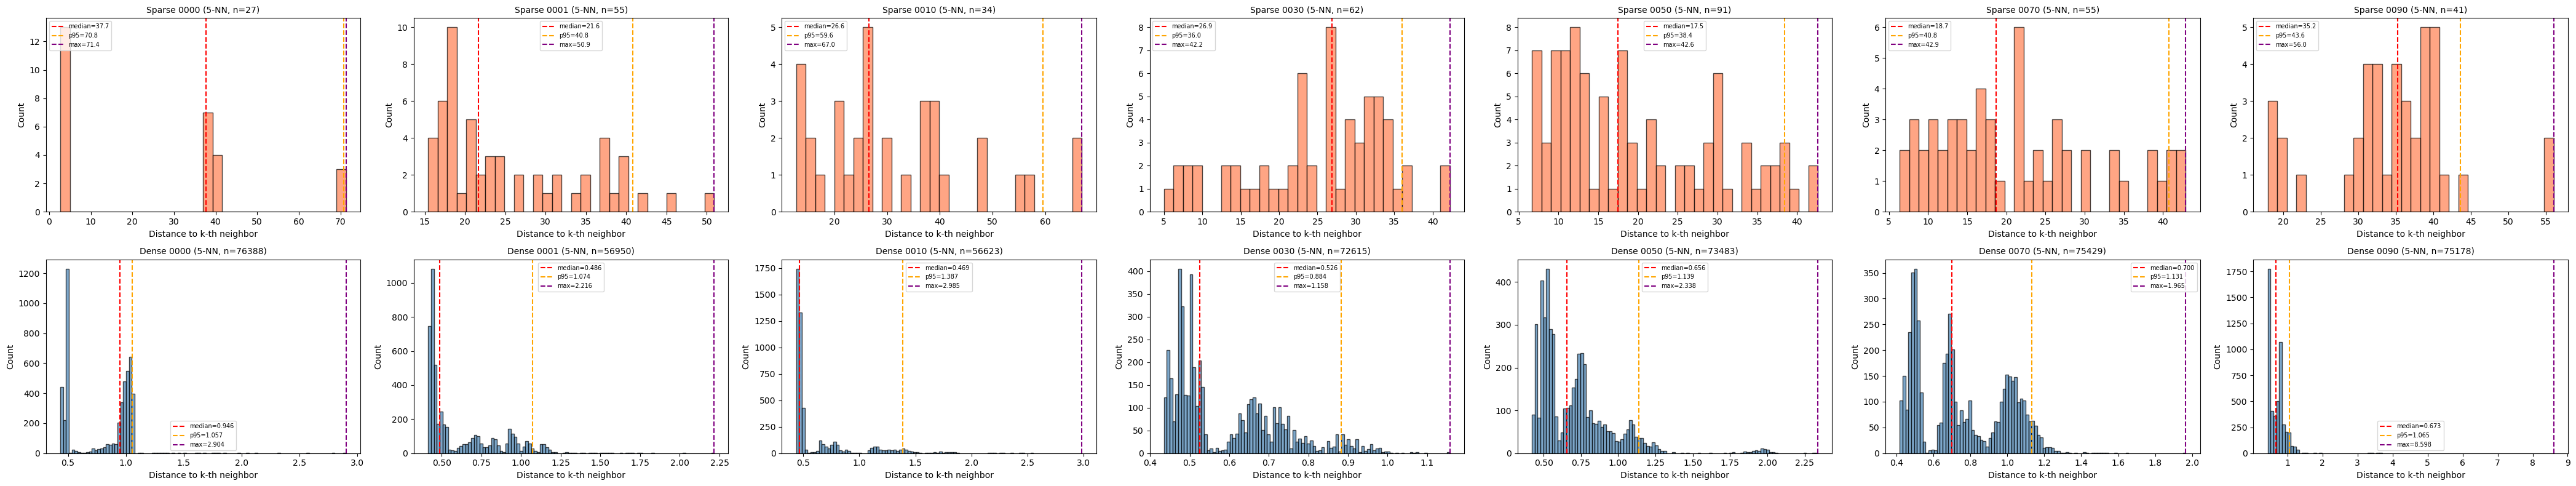

In [8]:
fig, axes = plt.subplots(2, len(IMAGE_INDICES), figsize=(6 * len(IMAGE_INDICES), 8))
if len(IMAGE_INDICES) == 1:
    axes = axes.reshape(2, 1)

for col, idx in enumerate(IMAGE_INDICES):
    # Sparse (상단)
    ax = axes[0, col]
    d = results_sparse[idx]["dists"]
    ax.hist(d, bins=30, edgecolor="black", alpha=0.7, color="coral")
    ax.axvline(np.median(d), color="red", ls="--", label=f"median={np.median(d):.1f}")
    ax.axvline(np.percentile(d, 95), color="orange", ls="--", label=f"p95={np.percentile(d, 95):.1f}")
    ax.axvline(d.max(), color="purple", ls="--", label=f"max={d.max():.1f}")
    ax.set_title(f"Sparse {idx:04d} ({MIN_NEIGHBORS}-NN, n={results_sparse[idx]['n_valid']})", fontsize=10)
    ax.set_xlabel("Distance to k-th neighbor")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)

    # Dense (하단)
    ax = axes[1, col]
    d = results_dense[idx]["dists"]
    ax.hist(d, bins=100, edgecolor="black", alpha=0.7, color="steelblue")
    ax.axvline(np.median(d), color="red", ls="--", label=f"median={np.median(d):.3f}")
    ax.axvline(np.percentile(d, 95), color="orange", ls="--", label=f"p95={np.percentile(d, 95):.3f}")
    ax.axvline(d.max(), color="purple", ls="--", label=f"max={d.max():.3f}")
    ax.set_title(f"Dense {idx:04d} ({MIN_NEIGHBORS}-NN, n={len(results_dense[idx]['points_3d'])})", fontsize=10)
    ax.set_xlabel("Distance to k-th neighbor")
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

## 7. Radius별 커버리지 분석 (Sparse)

In [9]:
test_radii = [0.5, 1.0, 1.5, 2.0, 5.0, 10.0, 20.0, 30.0, 50.0]

print(f"{'Radius':>8} | ", end="")
for idx in IMAGE_INDICES:
    print(f"  img{idx:04d}", end="")
print()
print("-" * (10 + 9 * len(IMAGE_INDICES)))

for r in test_radii:
    print(f"{r:>8.1f} | ", end="")
    for idx in IMAGE_INDICES:
        dists = results_sparse[idx]["dists"]
        coverage = (dists <= r).mean() * 100
        print(f"  {coverage:5.1f}%", end="")
    print()

  Radius |   img0000  img0001  img0010  img0030  img0050  img0070  img0090
-------------------------------------------------------------------------
     0.5 |     0.0%    0.0%    0.0%    0.0%    0.0%    0.0%    0.0%
     1.0 |     0.0%    0.0%    0.0%    0.0%    0.0%    0.0%    0.0%
     1.5 |     0.0%    0.0%    0.0%    0.0%    0.0%    0.0%    0.0%
     2.0 |     0.0%    0.0%    0.0%    0.0%    0.0%    0.0%    0.0%
     5.0 |    48.1%    0.0%    0.0%    0.0%    0.0%    0.0%    0.0%
    10.0 |    48.1%    0.0%    0.0%   11.3%   16.5%   12.7%    0.0%
    20.0 |    48.1%   38.2%   20.6%   25.8%   60.4%   50.9%    7.3%
    30.0 |    48.1%   69.1%   55.9%   64.5%   80.2%   80.0%   19.5%
    50.0 |    88.9%   98.2%   88.2%  100.0%  100.0%  100.0%   95.1%


## 8. Radius별 커버리지 분석 (Dense, 비교용)

In [10]:
test_radii_dense = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 5.0]

print(f"{'Radius':>8} | ", end="")
for idx in IMAGE_INDICES:
    print(f"  img{idx:04d}", end="")
print()
print("-" * (10 + 9 * len(IMAGE_INDICES)))

for r in test_radii_dense:
    print(f"{r:>8.1f} | ", end="")
    for idx in IMAGE_INDICES:
        dists = results_dense[idx]["dists"]
        coverage = (dists <= r).mean() * 100
        print(f"  {coverage:5.1f}%", end="")
    print()

  Radius |   img0000  img0001  img0010  img0030  img0050  img0070  img0090
-------------------------------------------------------------------------
     0.5 |    13.3%   54.8%   66.5%   33.8%   18.2%   22.6%   22.2%
     1.0 |    67.3%   91.2%   85.7%   99.7%   87.9%   76.1%   91.5%
     1.5 |    99.7%   99.6%   97.2%  100.0%   98.6%   99.9%   99.4%
     2.0 |    99.9%  100.0%   99.4%  100.0%   99.7%  100.0%   99.5%
     2.5 |    99.9%  100.0%   99.9%  100.0%  100.0%  100.0%   99.6%
     3.0 |   100.0%  100.0%  100.0%  100.0%  100.0%  100.0%   99.6%
     5.0 |   100.0%  100.0%  100.0%  100.0%  100.0%  100.0%   99.9%


## 9. 결론

| | Dense (~7만 pts) | Sparse (27~91 kp) |
|---|---|---|
| 5-NN median | ~0.3 units | **17~37 units** |
| 5-NN p95 | ~1.1 units | **36~71 units** |
| radius=1.0 커버리지 | 67~99% | **0%** |

- **Sparse keypoint만으로 FPFH를 계산하면**, radius=1.0에서 이웃이 0개 → descriptor 전부 0
- radius=50으로 올려도 모든 keypoint가 서로 이웃 → 로컬 기하 정보 소실
- **올바른 방법**: Dense point cloud에서 FPFH 계산 → keypoint 위치의 descriptor를 lookup

## 10. Dense FPFH Descriptor 계산 (keypoint lookup)

In [ ]:
def compute_dense_fpfh_for_keypoints(depth_real, kp_2d, n_valid, K,
                                     fpfh_radius=1.0, fpfh_max_nn=100):
    fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
    max_n = len(kp_2d)
    fpfh_out = np.zeros((max_n, 33), dtype=np.float32)
    if n_valid < 3:
        return fpfh_out
    # 1) Dense point cloud
    vs, us = np.where(depth_real > 0)
    zs = depth_real[vs, us]
    xs = (us - cx) * zs / fx
    ys = (vs - cy) * zs / fy
    dense_pts = np.stack([xs, ys, zs], axis=1).astype(np.float64)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(dense_pts)
    # 2) FPFH 계산
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=fpfh_radius * 2, max_nn=30)
    )
    fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd,
        o3d.geometry.KDTreeSearchParamHybrid(radius=fpfh_radius, max_nn=fpfh_max_nn),
    )
    fpfh_dense = np.array(fpfh.data).T.astype(np.float32)
    # 3) pixel_to_idx 직접 매핑으로 lookup
    pixel_to_idx = {(int(v), int(u)): i for i, (v, u) in enumerate(zip(vs, us))}
    for i in range(n_valid):
        u, v = int(kp_2d[i, 0]), int(kp_2d[i, 1])
        u = np.clip(u, 0, depth_real.shape[1] - 1)
        v = np.clip(v, 0, depth_real.shape[0] - 1)
        if (v, u) in pixel_to_idx:
            fpfh_out[i] = fpfh_dense[pixel_to_idx[(v, u)]]
    # L2 normalize
    norms = np.linalg.norm(fpfh_out[:n_valid], axis=1, keepdims=True)
    fpfh_out[:n_valid] = fpfh_out[:n_valid] / (norms + 1e-8)
    return fpfh_out

FPFH_RADIUS = 1.0
VIS_IDX = 0
img_path = DATA_DIR / f'depth_raw_{VIS_IDX:04d}.png'
ini_path = DATA_DIR / f'calib_{VIS_IDX:04d}.ini'
raw, depth_norm, depth_real, K = load_depth(img_path, ini_path)
h, w = depth_norm.shape
with torch.no_grad():
    img_t = torch.from_numpy(depth_norm).unsqueeze(0).unsqueeze(0).cuda()
    pred = sp_model({'image': img_t, 'image_size': torch.tensor([[h, w]])})
kp_raw = pred['keypoints'][0].cpu().numpy()
sc_raw = pred['keypoint_scores'][0].cpu().numpy()
valid = [i for i in range(len(kp_raw))
         if raw[int(np.clip(kp_raw[i,1],0,h-1)), int(np.clip(kp_raw[i,0],0,w-1))] > 0]
kp_v = kp_raw[valid]; sc_v = sc_raw[valid]
order = np.argsort(-sc_v)
kp_v = kp_v[order[:MAX_KP]]
n_valid = len(kp_v)
fpfh_desc = compute_dense_fpfh_for_keypoints(depth_real, kp_v, n_valid, K, FPFH_RADIUS)
print(f'Image {VIS_IDX:04d}: n_valid={n_valid}, fpfh shape={fpfh_desc[:n_valid].shape}')
zero_count = (np.abs(fpfh_desc[:n_valid]).sum(axis=1) < 1e-6).sum()
print(f'Zero descriptors: {zero_count}/{n_valid}')
print(f'Descriptor stats: min={fpfh_desc[:n_valid].min():.4f}, '
      f'max={fpfh_desc[:n_valid].max():.4f}, mean={fpfh_desc[:n_valid].mean():.4f}')


## 11. 샘플 Keypoint Descriptor Bar Chart

In [ ]:
N_SHOW = 8
n_show = min(N_SHOW, n_valid)
fig, axes = plt.subplots(2, n_show // 2, figsize=(4 * (n_show // 2), 6))
axes = axes.flatten()
for i in range(n_show):
    ax = axes[i]
    ax.bar(range(33), fpfh_desc[i], color='steelblue', alpha=0.8)
    ax.set_title(f'KP #{i}  ({kp_v[i,0]:.0f},{kp_v[i,1]:.0f})', fontsize=9)
    ax.set_xlabel('FPFH bin (33-dim)')
    ax.set_ylabel('value')
    ax.set_xlim(-1, 33)
    ax.axhline(0, color='black', linewidth=0.5)
plt.suptitle(f'Dense FPFH Descriptors - Image {VIS_IDX:04d} (radius={FPFH_RADIUS})', fontsize=12)
plt.tight_layout()
plt.show()


## 12. Descriptor Heatmap & Keypoint 오버레이

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ax = axes[0]
im = ax.imshow(fpfh_desc[:n_valid], aspect='auto', cmap='viridis', interpolation='nearest')
ax.set_xlabel('FPFH bin (33-dim)')
ax.set_ylabel('Keypoint index (score 순)')
ax.set_title(f'FPFH Descriptor Heatmap\n(n_valid={n_valid}, radius={FPFH_RADIUS})')
plt.colorbar(im, ax=ax)
ax = axes[1]
ax.imshow(depth_norm, cmap='gray')
desc_norms = np.linalg.norm(fpfh_desc[:n_valid], axis=1)
sc = ax.scatter(kp_v[:n_valid, 0], kp_v[:n_valid, 1],
               c=desc_norms, cmap='RdYlGn', s=30, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label='descriptor L2 norm (0=zero, 1=valid)')
ax.set_title('Keypoints on Depth Image\n(green=valid FPFH, red=zero)')
ax.set_axis_off()
plt.suptitle(f'Image {VIS_IDX:04d} - Dense FPFH (radius={FPFH_RADIUS})', fontsize=12)
plt.tight_layout()
plt.show()


## 13. Sparse(zero) vs Dense(valid) Heatmap 비교

In [ ]:
def compute_sparse_fpfh(depth_real, kp_2d, n_valid, K, fpfh_radius=1.0, fpfh_max_nn=100):
    fx, fy, cx, cy = K[0,0], K[1,1], K[0,2], K[1,2]
    fpfh_out = np.zeros((len(kp_2d), 33), dtype=np.float32)
    if n_valid < 3:
        return fpfh_out
    pts = []
    for i in range(n_valid):
        u, v = int(kp_2d[i,0]), int(kp_2d[i,1])
        u = np.clip(u, 0, depth_real.shape[1]-1)
        v = np.clip(v, 0, depth_real.shape[0]-1)
        z = float(depth_real[v, u])
        pts.append([(u-cx)*z/fx, (v-cy)*z/fy, z])
    pts = np.array(pts, dtype=np.float64)
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(pts)
    pcd.estimate_normals(
        search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=fpfh_radius*2, max_nn=30))
    fpfh = o3d.pipelines.registration.compute_fpfh_feature(
        pcd, o3d.geometry.KDTreeSearchParamHybrid(radius=fpfh_radius, max_nn=fpfh_max_nn))
    fpfh_np = np.array(fpfh.data).T.astype(np.float32)
    norms = np.linalg.norm(fpfh_np, axis=1, keepdims=True)
    fpfh_out[:n_valid] = fpfh_np / (norms + 1e-8)
    return fpfh_out

fpfh_sparse = compute_sparse_fpfh(depth_real, kp_v, n_valid, K, FPFH_RADIUS)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
im = ax.imshow(fpfh_sparse[:n_valid], aspect='auto', cmap='viridis',
               interpolation='nearest', vmin=0, vmax=0.5)
ax.set_xlabel('FPFH bin (33-dim)')
ax.set_ylabel('Keypoint index')
ax.set_title(f'Sparse FPFH (기존) - 전부 zero\n(radius={FPFH_RADIUS})')
plt.colorbar(im, ax=ax)
ax = axes[1]
im = ax.imshow(fpfh_desc[:n_valid], aspect='auto', cmap='viridis',
               interpolation='nearest', vmin=0, vmax=0.5)
ax.set_xlabel('FPFH bin (33-dim)')
ax.set_ylabel('Keypoint index')
ax.set_title(f'Dense FPFH (신규) - keypoint lookup\n(radius={FPFH_RADIUS})')
plt.colorbar(im, ax=ax)
plt.suptitle(f'Image {VIS_IDX:04d}: Sparse vs Dense FPFH 비교', fontsize=12)
plt.tight_layout()
plt.show()

sparse_zero = (np.abs(fpfh_sparse[:n_valid]).sum(axis=1) < 1e-6).sum()
dense_zero  = (np.abs(fpfh_desc[:n_valid]).sum(axis=1) < 1e-6).sum()
print(f'Sparse zero descriptors: {sparse_zero}/{n_valid}')
print(f'Dense  zero descriptors: {dense_zero}/{n_valid}')
